In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Read event_outputs.txt ────────────────────────────────────────────────────
event_data = np.loadtxt('event_outputs.txt', skiprows=1)
ev_time       = event_data[:, 1]
ev_oxi_events = event_data[:, 2]
ev_red_events = event_data[:, 3]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(ev_time, ev_oxi_events, color='tab:orange', linewidth=1.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Cumulative Oxidation Events')
axes[0].set_title('Oxi_events vs. Time')

axes[1].plot(ev_time, ev_red_events, color='tab:blue', linewidth=1.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Cumulative Reduction Events')
axes[1].set_title('Red_events vs. Time')

fig.tight_layout()
fig.savefig('event_outputs_plot.png', dpi=150)
plt.show()

# ── Read raw_outputs.txt ──────────────────────────────────────────────────────
raw_data = np.loadtxt('raw_outputs.txt', skiprows=1)
raw_time = raw_data[:, 1]
raw_CuI  = raw_data[:, 2]
raw_CuII = raw_data[:, 3]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(raw_time, raw_CuI, color='tab:green', linewidth=1.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Number of Cu(I)')
axes[0].set_title('CuI vs. Time')

axes[1].plot(raw_time, raw_CuII, color='tab:red', linewidth=1.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Number of Cu(II)')
axes[1].set_title('CuII vs. Time')

fig.tight_layout()
plt.show()

FileNotFoundError: event_outputs.txt not found.

In [ ]:
a = np.array([13.6750, 0.0000, 0.0000])
b = np.array([-6.8375, 11.8429, 0.0000])
c = np.array([0.0000,  0.0000, 14.7670])

V_uc = abs(np.dot(a, np.cross(b, c)))     # unit cell volume in Å³
# print(f"Unit cell volume:      {V_uc:.2f} Å³")

# 9x9x9 supercell (from box_input.dat: a_reps=9, b_reps=9, c_reps=9)
n_uc = 9 * 9 * 9
V_total_A3  = V_uc * n_uc                 # Å³
V_total_cm3 = V_total_A3 * 1e-24          # cm³  (1 Å = 1e-8 cm)

N_Cu = next(
    int(line.split()[1])
    for line in open("box_input.dat")
    if line.startswith("N_Copper")
)

rho_cu_1000A3 = N_Cu / V_total_A3 * 1000   # Cu per 1000 Å³

P_O2 = next(
    int(line.split()[1])
    for line in open("simulation_input.dat")
    if line.startswith("O2_pressure")
)
print(N_Cu, rho_cu_1000A3, P_O2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

raw_data = np.loadtxt('raw_outputs.txt', skiprows=1)
raw_time = raw_data[:, 1]
raw_CuI  = raw_data[:, 2]
raw_CuII = raw_data[:, 3]
raw_tot  = (raw_CuI+raw_CuII)[-1]
avg = np.average(raw_CuII[np.where(ev_time==200)[0][0]:]/raw_tot)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.plot(raw_time, raw_CuII/raw_tot)
ax.axhline(y=avg,label='Average')
ax.set_ylim(0,1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cu(II) Fraction')
ax.legend()
ax.tick_params(direction='in')
fig.tight_layout()
fig.savefig('fraction.png', dpi=150)
plt.show()

print(f'System:\nN_Cu:{N_Cu}\nrho_cu:{rho_cu_1000A3}\nP_O2:{P_O2}')
print(f'Fraction of Cu(II): {avg:.3f}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ── Read event_outputs.txt ────────────────────────────────────────────────────
event_data    = np.loadtxt('event_outputs.txt', skiprows=1)
ev_time       = event_data[:, 1]
ev_oxi_events = event_data[:, 2]
ev_red_events = event_data[:, 3]

# ── Linear regression on steady-state window ─────────────────────────────────
x = ev_time[np.where(ev_time==200)[0][0]:]
y = ev_red_events[np.where(ev_time==200)[0][0]:]

slope, intercept, r_value, p_value, std_err = linregress(x, y)
y_fit = slope * x + intercept

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.plot(ev_time, ev_red_events, color='tab:blue', linewidth=1.5, label='Red_events')
ax.plot(x, y_fit, color='tab:red', linewidth=1.5, linestyle='--',
      label=f'Linear fit (slope = {slope:.4f})')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative Reduction Events')
ax.tick_params(direction='in')
ax.legend()
fig.tight_layout()
fig.savefig('rate.png', dpi=150)
plt.show()

# Once you have the slope, the steady-state rate per Cu is:

N_Cu = next(
    int(line.split()[1])
    for line in open("box_input.dat")
    if line.startswith("N_Copper")
)
r = slope / N_Cu

print(f'System:\nN_Cu:{N_Cu}\nrho_cu:{rho_cu_1000A3}\nP_O2:{P_O2}')
print(f"Slope (d Red_events / dt) = {slope:.6f} events/s")
print(f"R²                        = {r_value**2:.6f}")
print(f"Steady-state rate per Cu  = {r:.6f} s⁻¹")

In [ ]:
import numpy as np

# CHA unit cell lattice vectors (from calculator.py line 889-891)
a = np.array([13.6750, 0.0000, 0.0000])
b = np.array([-6.8375, 11.8429, 0.0000])
c = np.array([0.0000,  0.0000, 14.7670])

V_uc = abs(np.dot(a, np.cross(b, c)))     # unit cell volume in Å³
# print(f"Unit cell volume:      {V_uc:.2f} Å³")

# 9x9x9 supercell (from box_input.dat: a_reps=9, b_reps=9, c_reps=9)
n_uc = 9 * 9 * 9
V_total_A3  = V_uc * n_uc                 # Å³
V_total_cm3 = V_total_A3 * 1e-24          # cm³  (1 Å = 1e-8 cm)
# print(f"Supercell volume:      {V_total_A3:.2f} Å³  =  {V_total_cm3:.4e} cm³")

# N_Copper = 610 (from box_input.dat)
N_Cu = next(
    int(line.split()[1])
    for line in open("box_input.dat")
    if line.startswith("N_Copper")
)
rho_cu_1000A3 = 0.083
Number_Cu = rho_cu_1000A3 * V_total_A3 / 1000
print(Number_Cu)
# rho_cu_1000A3 = 145 / V_total_A3 * 1000   # Cu per 1000 Å³
# print(f"Cu density: {rho_cu_1000A3:.4f} Cu / 1000 Å³")

# # Convert to mol/cm³
# from scipy.constants import Avogadro
# rho_cu_mol = rho_cu / Avogadro
# print(f"Cu density:            {rho_cu_mol:.4e} mol/cm³")

In [ ]:
np.linspace(0,70,10)

In [ ]:
for i in np.linspace(1,70,10):
    print(i)

In [ ]:
with open('rate_output.txt', 'w') as f:
  f.write(f'{r}\n')

In [3]:
from zmc import Zmc

In [19]:
import numpy as np
r_list = []
for i in np.linspace(1,70,10):
        calc = Zmc(Ar=0.023, Ap=52.103, P_O2=i, D=20.0, rho_Cu=0.083)
        calc.calculate()
        rate = calc.calc_rate()
        print(f'SCR rate is {rate:.3f} mol NO / (mol Cu * S)^-1')
        r_list.append(rate)

SCR rate is 0.001 mol NO / (mol Cu * S)^-1
SCR rate is 0.006 mol NO / (mol Cu * S)^-1
SCR rate is 0.009 mol NO / (mol Cu * S)^-1
SCR rate is 0.010 mol NO / (mol Cu * S)^-1
SCR rate is 0.011 mol NO / (mol Cu * S)^-1
SCR rate is 0.012 mol NO / (mol Cu * S)^-1
SCR rate is 0.013 mol NO / (mol Cu * S)^-1
SCR rate is 0.013 mol NO / (mol Cu * S)^-1
SCR rate is 0.014 mol NO / (mol Cu * S)^-1
SCR rate is 0.014 mol NO / (mol Cu * S)^-1


In [20]:
r_list

[np.float64(0.0011963744733967858),
 np.float64(0.0060395007021376195),
 np.float64(0.00854056483070682),
 np.float64(0.010066668747074427),
 np.float64(0.011141588391324701),
 np.float64(0.011949346231861446),
 np.float64(0.012589545951006397),
 np.float64(0.013119101263847716),
 np.float64(0.013535172413793104),
 np.float64(0.013913041036043064)]

(0.0, 70.0)

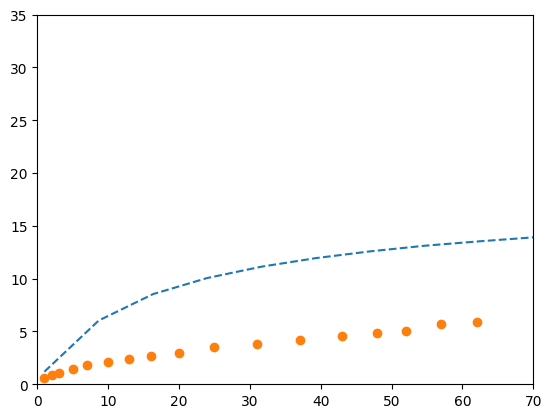

In [28]:
O_list = np.linspace(1,70,10)
r = np.array(r_list)*1e3
x = np.array([

    1, 2, 3, 5, 7, 10, 13, 16,

    20, 25, 31, 37, 43, 48, 52,

    57, 62

])

y = np.array([

    0.6, 0.9, 1.1, 1.4, 1.8, 2.1, 2.4, 2.7,

    3.0, 3.5, 3.8, 4.2, 4.6, 4.9, 5.0,

    5.7, 5.9

])

plt.plot(O_list,r,'--')
plt.plot(x,y,'o')
plt.ylim(0,35)
plt.xlim(0,70)